In [527]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.plot_styles import *

In [528]:

input_filenames = [
        "Level_35x25/Volume_CSV/results.csv",
        "Level_137x97/Volume_CSV/results.csv",
        # "Level_273x193/Volume_CSV/results.csv",
        ]

labels = [
        r'35x25',
        r'137x97',
        # r'273x193',
        # r'Fine'
]
lstyles = [
        '--',
        '-.',
        ':',
]


In [529]:
# reference quantities
p_ref = 101325
T_ref = 300
Rair = 287.06
gamma = 1.4
M_ref = 0.2
rho_ref = p_ref / (Rair * T_ref)
a_ref = np.sqrt(gamma * Rair * T_ref)
q_ref = 0.5 * rho_ref * a_ref**2 * M_ref**2

nu_ref = 1.84e-5
mu_ref = nu_ref * rho_ref

In [530]:
datas = {}

for ii,input_filename in enumerate(input_filenames):
    with open(input_filename, 'r') as f:
            ni = int(f.readline().strip().split('=')[1])
            nj = int(f.readline().strip().split('=')[1])
            nk = int(f.readline().strip().split('=')[1])
        
    df = pd.read_csv(input_filename, skiprows=3)
    data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    datas[ii] = data

In [531]:
def compute_cp(p):
    return (p-p_ref) / q_ref

def compute_cf(tau_x):
    return tau_x / q_ref

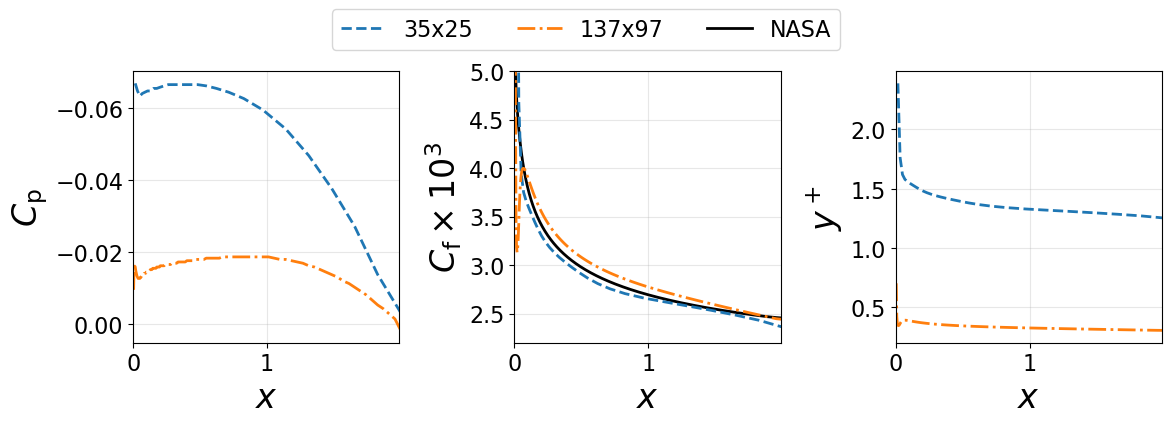

In [541]:

xmin = 0.00

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

nasa = np.loadtxt('reference/cf_plate.dat', skiprows=2)
ax[1].plot(nasa[:, 0], nasa[:, 1]*1e3, label='NASA', color='k', lw=2)

for key, data in datas.items():
    mask = (data['x'][:, 0, 0] > xmin)
    idx = np.where(mask)[0]

    p = data['Pressure'][idx, 0, 0]
    x = data['x'][idx, 0, 0]
    tau_x = data['Wall Shear Stress X'][idx, 0, 0]
    tau_y = data['Wall Shear Stress Y'][idx, 0, 0]
    tau = np.sqrt(tau_x**2 + tau_y**2)
    yplus = data['Y Plus'][idx, 0, 0]
    
    ax[0].plot(x, compute_cp(p), lstyles[key], mfc='none',label=labels[key], lw=2)
    
    
    ax[1].plot(x, compute_cf(tau)*1e3, lstyles[key], lw=2)
    ax[2].plot(x, yplus, lstyles[key], lw=2)


fig.legend(ncol=len(input_filenames)+1, bbox_to_anchor=(0.5, 1.1), loc='upper center')
ax[0].invert_yaxis()
ax[0].set_ylabel(r'$C_{\rm p}$')
ax[0].set_xlabel(r'$x$')
ax[0].grid(alpha=0.3)
ax[0].set_xlim(0.0, 1.99)

ax[1].set_ylabel(r'$C_{\rm f} \times 10^3$')
ax[1].set_xlabel(r'$x$')
ax[1].grid(alpha=0.3)
ax[1].set_ylim(2.2, 5)
ax[1].set_xlim(0.0, 1.99)

ax[2].set_ylabel(r'$y^+$')
ax[2].set_xlabel(r'$x$')
ax[2].grid(alpha=0.3)
ax[2].set_xlim(0.0, 1.99)

fig.tight_layout()
fig.savefig('flatplate_results_comparison.pdf', bbox_inches='tight')


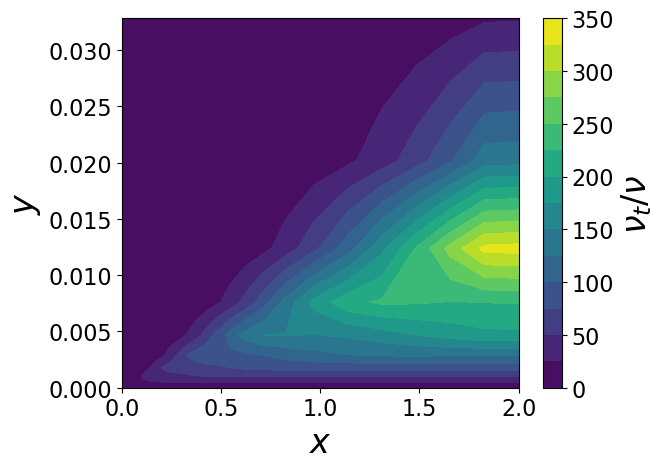

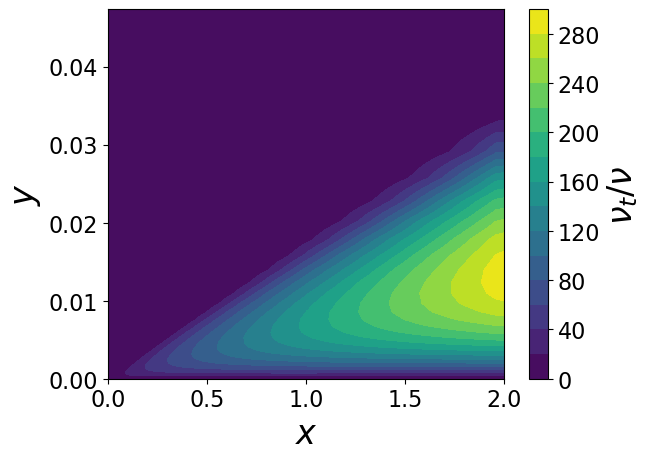

In [533]:
xmin = 0.0
xmax = 2.0
ymin = 0.00
ymax = 0.05

for key, data in datas.items():
    X = data['x'][:, :, 0]

    Y = data['y'][:, :, 0]

    EV = data['Eddy Viscosity'][:, :, 0]

    i_mask = np.any((X >= xmin) & (X <= xmax), axis=1)

    j_mask = np.any((Y >= ymin) & (Y <= ymax), axis=0)

    Xp = X[np.ix_(i_mask, j_mask)]

    Yp = Y[np.ix_(i_mask, j_mask)]

    mu_t = EV[np.ix_(i_mask, j_mask)]

    plt.figure()

    plt.contourf(Xp, Yp, mu_t/mu_ref, levels=15, cmap='viridis')
    plt.colorbar(label=r'$\nu_t / \nu$')

    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    

Text(0.5, 1.0, 'station x=0.97')

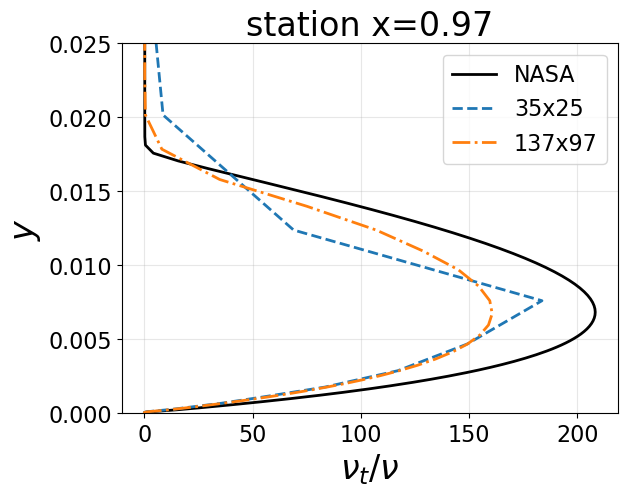

In [534]:
xcheck = 0.97

nasa = np.loadtxt('reference/mut_0.97.dat', skiprows=2)

plt.figure()
plt.plot(nasa[:, 2], nasa[:, 1], label='NASA', color='k', lw=2)

for key, data in datas.items():
    idxX = np.argmin(np.abs(data['x'][:, 0, 0] - xcheck))
    y = data['y'][idxX, :, 0]
    
    mu_t = data['Eddy Viscosity'][idxX, :, 0]
    
    plt.plot(mu_t/mu_ref, y, lstyles[key], label=labels[key], lw=2)

plt.ylim(0, 0.025)
plt.xlabel(r'$\nu_t / \nu$')
plt.ylabel(r'$y$')
plt.legend()
plt.grid(alpha=0.3)
plt.title(f'station x={xcheck}')

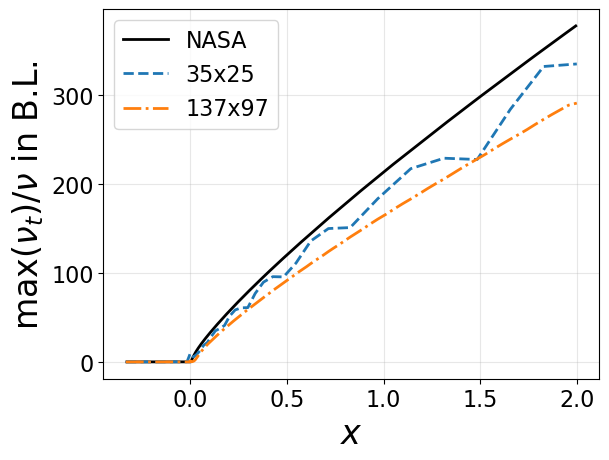

In [535]:
nasa = np.loadtxt('reference/find_peak_mut.dat', skiprows=1)
plt.plot(nasa[:, 0], nasa[:, 1], label='NASA', color='k', lw=2)
for key, data in datas.items():
    x = data['x'][:, 0, 0]
    mut = data['Eddy Viscosity'][:, :, 0]

    max_mut = np.max(mut, axis=1)
    max_mut_ratio = max_mut / mu_ref
    
    plt.plot(x, max_mut_ratio, ls=lstyles[key], label=labels[key], lw=2)

plt.xlabel(r'$x$')
plt.ylabel(r'$\max(\nu_t) / \nu$ in B.L.')
plt.legend()
plt.grid(alpha=0.3)

/var/folders/qw/6fnq0nmj7c12cp5hqhwjb1lhzhstpw/T/ipykernel_21060/4100501276.py:15: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(yplus), uplus, lstyles[key], label=labels[key], lw=2)


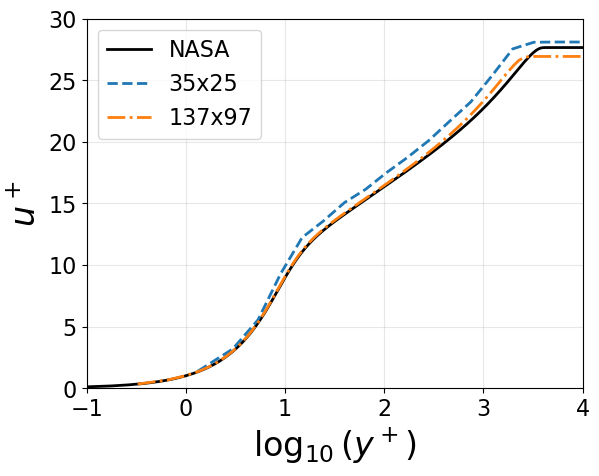

In [536]:

nasa = np.loadtxt('reference/sa-upyp_cfl3d.dat', skiprows=3)
plt.plot(nasa[:, 0], nasa[:, 1], label='NASA', color='k', lw=2)

check_x = 0.97
for key, data in datas.items():
    idxX = np.argmin(np.abs(data['x'][:, 0, 0] - xcheck))
    y = data['y'][idxX, :, 0]
    tauw = np.sqrt(data['Wall Shear Stress Y'][idxX, 0, 0]**2 + data['Wall Shear Stress X'][idxX, 0, 0]**2)
    u = data['Velocity X'][idxX, :, 0]
    rhow = data['Density'][idxX, 0, 0]
    uplus = u / np.sqrt(tauw/rhow)
    nuw = data['Molecular Viscosity'][idxX, 0, 0]/rhow
    yplus = y *np.sqrt(tauw/rhow) / nuw
    
    plt.plot(np.log10(yplus), uplus, lstyles[key], label=labels[key], lw=2)
plt.xlim(-1, 4)
plt.ylim(0, 30)
plt.grid(alpha=0.3)
plt.xlabel(r'$\log_{10}(y^+$)')
plt.ylabel(r'$u^+$')
plt.legend()